<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 6 — Perceptrón, MLP, Backpropagation y Métricas Clínicas</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

En el Challenge 5 trabajaste con el dataset **Breast Cancer Wisconsin** como problema no supervisado: aplicaste PCA, K-means y DBSCAN sin usar las etiquetas durante el entrenamiento.

Ahora usaremos el **mismo contexto biomédico**, pero como problema supervisado de clasificación binaria. Cada muestra corresponde a características morfológicas calculadas a partir de imágenes digitalizadas de aspirado con aguja fina (FNA) de masa mamaria. El objetivo será entrenar modelos neuronales en **PyTorch** para clasificar si una muestra corresponde a un tumor **maligno** o **benigno**.

**Pregunta clínica:** ¿puede una red neuronal simple mejorar la clasificación diagnóstica frente a un perceptrón/modelo lineal? ¿Qué métrica debería priorizarse si el error más crítico es no detectar un tumor maligno?

---
> **Fuente:** Wolberg, W. H. et al. (1995). *Breast Cancer Wisconsin (Diagnostic) Dataset*. UCI ML Repository.  
> Disponible directamente en `sklearn.datasets.load_breast_cancer()` — no requiere descarga.

### Estructura de carpetas
```text
Clase10_Challenge6/
└── Challenge6_ApellidoNombre.ipynb    ← no se necesita CSV externo
```

**Nota importante:** en `sklearn`, la etiqueta original es `0 = malignant` y `1 = benign`. En este challenge invertiremos la codificación para trabajar clínicamente con:

```text
0 = benigno
1 = maligno  ← clase positiva clínica
```


## Ejercicio 1 — Diseño previo al código

### 1.1 — Neurona artificial, perceptrón y MLP

**1.** Completa la expresión general de una neurona artificial:

$$z = \mathbf{w}^T \mathbf{x} + b \qquad ; \qquad a = \phi(z)$$

#### ¿Qué representan $\mathbf{x}$, $\mathbf{w}$, $b$ y $\phi$ en este problema biomédico?

* **$\mathbf{x}$:** Representa el vector de entradas. Es decir, los datos clínicos o biomarcadores extraídos del paciente
* **$\mathbf{w}$:** Representa el vector de pesos. Es decir, el peso o la relevancia clínica que el modelo asigna a cada característica de entrada. 
* **$b$ :** Representa el sesgo. Se puede interpretar como una predisposición del modelo basada en la prevalencia de la enfermedad antes de evaluar las características del paciente.
* **$\phi$ :** Representa la función de activación. Es decir, la función no lineal que transforma la combinación lineal $z$ en un valor entre $0$ y $1$. Esto permite interpretar la salida de la neurona como la probabilidad de que el tumor sea maligno o no.

---

**2.** Explica la diferencia entre un perceptrón/modelo lineal y un MLP.

| Modelo | ¿Qué aprende? | Tipo de frontera de decisión |
| :--- | :--- | :--- |
| **Perceptrón / modelo lineal** | Aprende una combinación directa de las variables de entrada sin transiciones intermedias. | **Lineal:** Un hiperplano que divide el espacio. |
| **MLP (Perceptrón Multicapa)** | Aprende representaciones jerárquicas de los datos mediante capas ocultas. | **No lineal:** Fronteras curvas o irregulares capaces de separar clases no lineales. |

---

**3.** ¿Por qué una salida de una sola neurona puede ser suficiente para clasificación binaria?

Porque se trata de un problema de clasificación binaria, es decir involucra únicamente dos clases  excluyentes (0 para benigno, 1 para maligno). Al utilizar una función de activación como la sigmoide en la neurona de salida, se puede generar un único valor en el intervalo $[0, 1]$ que representa la probabilidad de pertenencia a la clase positiva. Es decir, si la salida es igual o mayor al umbral se clasifica como maligno, y si es menor, como benigno.

---

**4.** En clasificación benigno/maligno, ¿qué error clínico es más grave: falso positivo o falso negativo? ¿Por qué?

El error clínico más grave es el falso negativo. Este error es grave porque implica clasificar un tejido maligno como benigno. Esta clasificación implicaría que el paciente no reciba el tratamiento oportuno, permitiendo la progresión de la enfermedad y el deterioro de su pronóstico.

### 1.2 — Backpropagation y función de pérdida

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

Para clasificación binaria usaremos una pérdida tipo Binary Cross-Entropy.

$$\hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

$$\mathcal{L}_{BCE} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

---

**2.** Ordena los pasos de entrenamiento en PyTorch:

| Paso | Código PyTorch | ¿Qué hace? |
| :--- | :--- | :--- |
| 1 | `logits = model(X_batch)` | Hace el Forward Pass, es decir,  produce un lote de datos por la red para obtener las predicciones crudas. |
| 2 | `loss = loss_fn(logits, y_batch)` | Hace el cálculo de la pérdida, es decir, cuantifica el error comparando las predicciones del modelo contra las etiquetas clínicas reales. |
| 3 | `optimizer.zero_grad()` | Hace limpieza de gradientes, es decir, borra los gradientes acumulados de la iteración anterior para que no se sumen a los nuevos. |
| 4 | `loss.backward()` |  Hace el calculo de derivadas, es decir, calcula los gradientes de la pérdida con respecto a todos los parámetros del modelo mediante la regla de la cadena. |
| 5 | `optimizer.step()` |Hace la actualización de parámetros, es decir, ajusta los pesos de la red utilizando los gradientes calculados para minimizar la pérdida. |

---

**3.** ¿Por qué en PyTorch primero calculamos la pérdida y recién después llamamos a `loss.backward()`?

Porque para poder corregir al modelo, primero necesitamos medir exactamente qué tan grande fue el error. La variable loss calcula ese error total. Una vez que tenemos ese resultado final, el método loss.backward() lo toma como punto de partida y va hacia atrás paso a paso para calcular cuánta culpa tuvo cada parámetro en ese error, lo que permite ajustarlos después.

### 1.3 — Pipeline completo

Completa el siguiente pipeline:

```text
load_breast_cancer()
        │
        ▼
[ Paso A ] Extracción de datos (X, y) y colocación de etiquetas (1=maligno, 0=benigno)
        │
        ▼
[ Paso B ] Split estratificado: División en train y test
        │
        ▼
[ Paso C ] StandardScaler
           fit en X_train ; transform en X_train y X_test
        │
        ▼
[ Paso D ] Conversión a torch.Tensor
           X: torch.float32 ; y: torch.float32 con shape (N, 1)
        │
        ▼
[ Paso E ] Creación de TensorDataset y DataLoader
        │
        ├──── Modelo 1: Perceptrón / Modelo Lineal (Regresión Logística en PyTorch)
        │
        └──── Modelo 2: MLP (Perceptrón Multicapa / Red Neuronal con capas ocultas)
        │
        ▼
[ Paso F ] Entrenamiento explícito:
           forward → loss (cálculo de pérdida) → zero_grad → backward() → step
        │
        ▼
[ Paso G ] Evaluación clínica:
           matriz de confusión, accuracy, sensibilidad,
           especificidad, precisión, F1, AUC-ROC (Área bajo la curva ROC)
```

**📝 Tu respuesta:** completa los blancos arriba.


---
## Ejercicio 2 — Setup y carga de datos

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>


### Paso 2.1 — Librerías

In [1]:
UPCH_RED    = '#8B0000'
UPCH_BLUE   = '#1565C0'
UPCH_GREEN  = '#2E7D32'
UPCH_ORANGE = '#E65100'
UPCH_PURPLE = '#6A1B9A'
UPCH_GRAY   = '#4A4A4A'

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# TODO 1: importa PyTorch y sus módulos principales
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_breast_cancer

# TODO 2: importa train_test_split, StandardScaler y métricas clínicas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

plt.rcParams['figure.dpi'] = 120

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# TODO 3: selecciona GPU si está disponible; si no, CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Setup completo ✓ | device = {device}')

Setup completo ✓ | device = cpu


### Paso 2.2 — Carga del dataset y recodificación clínica

In [2]:
# ── Carga del dataset ──────────────────────────────────────────
data = load_breast_cancer()
X = data.data.astype(np.float32)
feature_names = data.feature_names

# sklearn: 0 = malignant, 1 = benign
# challenge: 0 = benigno, 1 = maligno (clase positiva clínica)
# TODO 4: invierte la etiqueta original para que 1 sea maligno
y = 1 - data.target


label_map = {0: 'Benigno', 1: 'Maligno'}
df = pd.DataFrame(X, columns=feature_names)
df['diagnosis'] = y

print(f'Shape X: {X.shape}')
print(f'Número de features: {X.shape[1]}')
print('Codificación usada en este challenge: 0=Benigno, 1=Maligno')
print('\nDistribución de clases:')
print(df['diagnosis'].map(label_map).value_counts())
df.head()

Shape X: (569, 30)
Número de features: 30
Codificación usada en este challenge: 0=Benigno, 1=Maligno

Distribución de clases:
diagnosis
Benigno    357
Maligno    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.990000,10.380000,122.800003,1001.000000,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.330000,184.600006,2019.000000,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.570000,17.770000,132.899994,1326.000000,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.410000,158.800003,1956.000000,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.690001,21.250000,130.000000,1203.000000,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.530001,152.500000,1709.000000,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.420000,20.379999,77.580002,386.100006,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.500000,98.870003,567.700012,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.290001,14.340000,135.100006,1297.000000,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.670000,152.199997,1575.000000,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### Paso 2.3 — EDA inicial

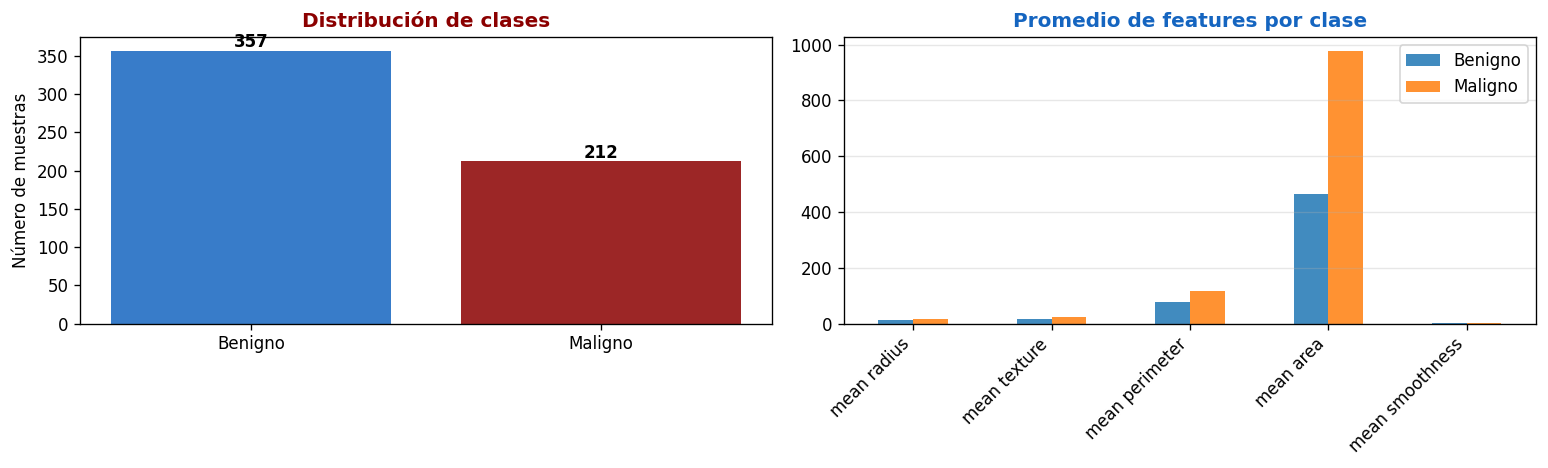

Resumen estadístico de las primeras 5 variables:


mean radius                                                  \
                count   mean   std    min    25%    50%    75%    max   
diagnosis                                                               
0               357.0  12.15  1.78   6.98  11.08  12.20  13.37  17.85   
1               212.0  17.46  3.20  10.95  15.08  17.32  19.59  28.11   

          mean texture         ... mean area         mean smoothness        \
                 count   mean  ...       75%     max           count  mean   
diagnosis                      ...                                           
0                357.0  17.91  ...    551.10   992.1           357.0  0.09   
1                212.0  21.60  ...   1203.75  2501.0           212.0  0.10   

                                               
            std   min   25%   50%   75%   max  
diagnosis                                      
0          0.01  0.05  0.08  0.09  0.10  0.16  
1          0.01  0.07  0.09  0.10  0.11  0.14  

[2 rows x 40 columns]

In [3]:
# ── Distribución de clases y resumen de features ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['diagnosis'].map(label_map).value_counts()
axes[0].bar(counts.index, counts.values, color=[UPCH_BLUE, UPCH_RED], alpha=0.85)
axes[0].set_title('Distribución de clases', fontsize=12, fontweight='bold', color=UPCH_RED)
axes[0].set_ylabel('Número de muestras')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

selected_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
df.groupby('diagnosis')[selected_features].mean().T.plot(kind='bar', ax=axes[1], alpha=0.85)
axes[1].set_title('Promedio de features por clase', fontsize=12, fontweight='bold', color=UPCH_BLUE)
axes[1].set_xticklabels(selected_features, rotation=45, ha='right')
axes[1].legend(['Benigno', 'Maligno'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('challenge6_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print('Resumen estadístico de las primeras 5 variables:')
df[selected_features + ['diagnosis']].groupby('diagnosis').describe().round(2)

### Paso 2.4 — Interpretación inicial

**📝 Tu respuesta (edita esta celda):**

**1. ¿El dataset está balanceado o desbalanceado?**  
El dataset presenta un ligero desbalance de clases, ya que contiene 357 muestras benignas (62.7%) y 212 muestras malignas (37.3%). Aunque la diferencia no es suficientemente grande como para considerarlo un caso severo de desbalance, sí existe una mayor representación de la clase benigna. Esto podría llevar al modelo a favorecer la predicción de la clase mayoritaria para obtener una mayor exactitud global. Por ello, durante la evaluación será importante utilizar métricas que analicen el desempeño por clase, especialmente sobre los casos malignos, en lugar de depender únicamente del accuracy.

**2. ¿Qué diferencias observas entre benigno y maligno en las variables exploradas?**  
Al comparar las variables exploradas entre ambas clases, se observa que los tumores malignos presentan, en promedio, valores más altos en características como mean radius, mean perimeter y mean area, lo que indica que suelen ser de mayor tamaño que los tumores benignos. Asimismo, variables como mean texture muestran diferencias que sugieren una mayor complejidad y variabilidad en la estructura del tejido maligno. Estas diferencias reflejan cambios morfológicos asociados al desarrollo del cáncer y permiten distinguir ambos tipos de tumores a partir de mediciones cuantitativas. La presencia de diferencias consistentes entre benignos y malignos es una señal de que las características del dataset poseen capacidad discriminativa, por lo que pueden ser utilizadas por un modelo de aprendizaje automático para identificar patrones asociados a cada diagnóstico y mejorar la precisión de la clasificación.

**3. ¿Qué métrica clínica deberíamos cuidar más si nos preocupa no perder casos malignos?**  
La métrica más importante en este contexto es el Recall o Sensibilidad de la clase maligna. Esta métrica mide la proporción de pacientes con cáncer que son correctamente identificados por el sistema. En aplicaciones médicas, un falso negativo representa un caso maligno que el modelo clasifica como benigno, lo que podría retrasar el diagnóstico y el inicio del tratamiento. Debido al riesgo clínico asociado a este tipo de error, es preferible maximizar la sensibilidad, incluso si esto implica aceptar un número moderado de falsos positivos que posteriormente puedan ser descartados mediante exámenes adicionales.

**4. ¿Por qué será necesario escalar las variables antes de entrenar una red neuronal?**  
El escalado de las variables es fundamental porque las características del dataset se encuentran en rangos muy distintos. Por ejemplo, variables como mean smoothness toman valores cercanos a 0.1, mientras que mean area puede alcanzar valores superiores a 1000. Si los datos se introducen directamente en la red neuronal, las variables de mayor magnitud tendrán una influencia desproporcionada en el cálculo de los gradientes y en la actualización de los pesos. Esto puede dificultar el aprendizaje y provocar una convergencia más lenta o inestable. Al escalar las variables, todas contribuyen en una magnitud similar, permitiendo que la red aprenda de manera más eficiente, estable y con mejor capacidad de generalización.


---
# PARTE 1 — De datos tabulares a tensores PyTorch
## Ejercicio 3 — Split, escalado y DataLoader

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>


### Paso 3.1 — Train / validation / test split

In [4]:
# ── Split estratificado ─────────────────────────────────────────
# TODO 5: separa primero test = 20% manteniendo proporción de clases
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# TODO 6: separa validation a partir de trainval
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print(f'Train:      {X_train.shape} | malignos={y_train.sum()}')
print(f'Validation: {X_val.shape} | malignos={y_val.sum()}')
print(f'Test:       {X_test.shape} | malignos={y_test.sum()}')

Train:      (341, 30) | malignos=127
Validation: (114, 30) | malignos=43
Test:       (114, 30) | malignos=42


### Paso 3.2 — Escalado sin data leakage

In [5]:
# ── StandardScaler: fit SOLO en train ───────────────────────────
scaler = StandardScaler()

# TODO 7: ajusta el scaler solo en train y transforma train/val/test
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('Media aproximada train escalado:', X_train_sc.mean(axis=0)[:3].round(4))
print('Desv. estándar train escalado:', X_train_sc.std(axis=0)[:3].round(4))

Media aproximada train escalado: [ 0.  0. -0.]
Desv. estándar train escalado: [1. 1. 1.]


### Paso 3.3 — Conversión a tensores y creación de DataLoaders

In [6]:
# ── Conversión a tensores ───────────────────────────────────────
# TODO 8: convierte X a tensores float32
X_train_t = torch.tensor(X_train_sc, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_sc, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_sc, dtype=torch.float32)

# TODO 9: convierte y a tensores float32 con shape (N, 1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val_t   = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

BATCH_SIZE = 32

# TODO 10: crea TensorDataset y DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t, y_val_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f'X_train_t: {X_train_t.shape} | y_train_t: {y_train_t.shape}')
print(f'Número de mini-batches train: {len(train_loader)}')

X_train_t: torch.Size([341, 30]) | y_train_t: torch.Size([341, 1])
Número de mini-batches train: 11


### Paso 3.4 — Inspección de un mini-batch

In [7]:
# ── Inspección de mini-batch ────────────────────────────────────
X_batch, y_batch = next(iter(train_loader))
print(f'X_batch shape: {X_batch.shape}')
print(f'y_batch shape: {y_batch.shape}')
print(f'Primeras etiquetas del batch: {y_batch[:8].view(-1).numpy().astype(int)}')
print('\nInterpretación: cada fila tiene ___ features; cada etiqueta tiene shape ___ para BCEWithLogitsLoss.')

X_batch shape: torch.Size([32, 30])
y_batch shape: torch.Size([32, 1])
Primeras etiquetas del batch: [0 1 0 1 0 0 0 1]

Interpretación: cada fila tiene ___ features; cada etiqueta tiene shape ___ para BCEWithLogitsLoss.


### Paso 3.5 — Interpretación

**📝 Tu respuesta (edita esta celda):**

**1. ¿Qué representa la dimensión 30 en `X_batch`?**  
La dimensión 30 en X_batch representa el número total de características (features) utilizadas para describir cada muestra del dataset. Estas variables corresponden a diferentes mediciones obtenidas a partir de imágenes de los tumores, incluyendo aspectos relacionados con tamaño, textura, perímetro, área y otras propiedades morfológicas. Cada una de estas características aporta información relevante sobre el tejido analizado, permitiendo que la red neuronal identifique patrones asociados a tumores benignos o malignos. Por lo tanto, cada fila del tensor constituye una representación numérica completa de un paciente basada en 30 variables predictoras.

**2. ¿Por qué `y_batch` tiene shape `(batch_size, 1)`?**  
El tensor y_batch tiene forma (batch_size, 1) porque cada muestra posee una única etiqueta asociada que indica la clase a la que pertenece, es decir, benigno (0) o maligno (1). Mantener esta estructura bidimensional garantiza la compatibilidad con la función de pérdida BCEWithLogitsLoss, la cual requiere que las etiquetas tengan la misma forma que las salidas generadas por la red neuronal. De esta manera, cada predicción producida por el modelo puede compararse directamente con su valor real correspondiente, permitiendo calcular correctamente el error y actualizar los parámetros durante el entrenamiento.

**3. ¿Por qué usamos `shuffle=True` en train y `shuffle=False` en validation/test?**  
Se utiliza shuffle=True en el conjunto de entrenamiento para mezclar aleatoriamente las muestras antes de cada época, evitando que la red neuronal aprenda patrones artificiales relacionados con el orden de los datos. Esta aleatorización favorece que los mini-batches sean más representativos de la distribución general del dataset y contribuye a un aprendizaje más robusto y con mejor capacidad de generalización. En contraste, en los conjuntos de validación y prueba se emplea shuffle=False porque estos datos no participan en la actualización de los pesos del modelo, sino únicamente en su evaluación. Mantener un orden fijo garantiza que las métricas obtenidas sean consistentes, reproducibles y comparables entre diferentes ejecuciones.

**4. ¿Para qué nos sirve separar validation y test?**  
La separación de los conjuntos de validation y test es fundamental para realizar una evaluación rigurosa del modelo. El conjunto de validación se utiliza durante el proceso de desarrollo para monitorear el desempeño del modelo, detectar posibles problemas de sobreajuste y ajustar hiperparámetros o decisiones de diseño sin recurrir a los datos de prueba. Por su parte, el conjunto de test permanece completamente aislado hasta la etapa final y actúa como una simulación de datos nuevos no vistos previamente. Esto permite obtener una estimación objetiva e imparcial de la capacidad de generalización del modelo, asegurando que el rendimiento reportado refleje de manera más realista su comportamiento en aplicaciones reales.

---
# PARTE 2 — Perceptrón / Clasificador Lineal en PyTorch
## Ejercicio 4 — Modelo lineal, entrenamiento y backpropagation

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>


### Paso 4.1 — Definición del modelo lineal

In [8]:
# ── Perceptrón / modelo lineal para clasificación binaria ──────
class LogisticPerceptron(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        # TODO 11: una capa lineal que reciba n_features y devuelva 1 logit
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        # TODO 12: calcula el logit
        logits = self.linear(x)
        return logits

n_features = X_train_t.shape[1]
perceptron = LogisticPerceptron(n_features).to(device)
print(perceptron)
print(f'Número de parámetros entrenables: {sum(p.numel() for p in perceptron.parameters())}')

LogisticPerceptron(
  (linear): Linear(in_features=30, out_features=1, bias=True)
)
Número de parámetros entrenables: 31


### Paso 4.2 — Funciones de entrenamiento y evaluación

In [9]:
# ── Funciones reutilizables de entrenamiento ───────────────────
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # TODO 13: completa el flujo forward → loss → zero_grad → backward → step
        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def evaluate_loss(model, loader, loss_fn, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def train_model(model, train_loader, val_loader, loss_fn, optimizer, epochs=100, device=device):
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss   = evaluate_loss(model, val_loader, loss_fn, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if epoch == 1 or epoch % 25 == 0:
            print(f'Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}')

    return history

### Paso 4.3 — Entrenamiento del perceptrón

In [10]:
# ── Entrenamiento del modelo lineal ─────────────────────────────
seed_everything(42)
perceptron = LogisticPerceptron(n_features).to(device)

# TODO 14: define la pérdida y el optimizador
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(perceptron.parameters(), lr=0.01)

hist_perc = train_model(perceptron, train_loader, val_loader,
                        loss_fn, optimizer, epochs=100, device=device)

Epoch 001 | train_loss=0.4549 | val_loss=0.3310
Epoch 025 | train_loss=0.0680 | val_loss=0.0732
Epoch 050 | train_loss=0.0554 | val_loss=0.0697
Epoch 075 | train_loss=0.0487 | val_loss=0.0727
Epoch 100 | train_loss=0.0443 | val_loss=0.0761


### Paso 4.4 — Curvas de pérdida

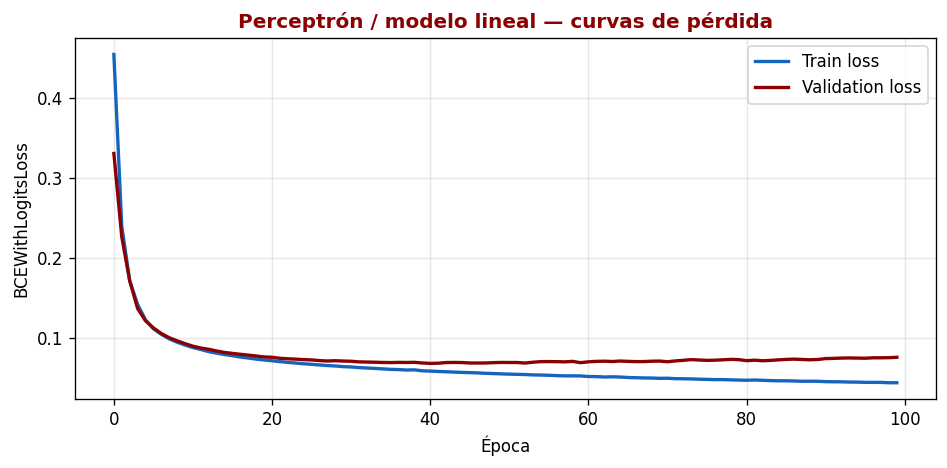

In [11]:
# ── Curvas de pérdida ───────────────────────────────────────────
def plot_history(history, title):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history['train_loss'], label='Train loss', color=UPCH_BLUE, lw=2)
    ax.plot(history['val_loss'], label='Validation loss', color=UPCH_RED, lw=2)
    ax.set_xlabel('Época')
    ax.set_ylabel('BCEWithLogitsLoss')
    ax.set_title(title, fontsize=12, fontweight='bold', color=UPCH_RED)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(hist_perc, 'Perceptrón / modelo lineal — curvas de pérdida')

### Paso 4.5 — Funciones de predicción y métricas clínicas

In [12]:
# ── Predicción y métricas clínicas ──────────────────────────────
@torch.no_grad()
def predict_proba(model, X_tensor, device):
    model.eval()
    logits = model(X_tensor.to(device))
    # TODO 15: convierte logits a probabilidades con sigmoid
    probs = torch.sigmoid(logits).cpu().numpy().ravel()
    return probs


def clinical_metrics(y_true, y_prob, threshold=0.5):
    # TODO 16: convierte probabilidades a clases usando threshold
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'sensitivity_recall_malignant': recall_score(y_true, y_pred, pos_label=1),
        'specificity_benign': tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        'precision_malignant': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_malignant': f1_score(y_true, y_pred, pos_label=1),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }


def plot_confusion(y_true, y_prob, title, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Reds')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Benigno', 'Maligno'])
    ax.set_yticklabels(['Benigno', 'Maligno'])
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_title(title, fontsize=11, fontweight='bold', color=UPCH_RED)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontweight='bold')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

### Paso 4.6 — Evaluación del perceptrón

In [13]:
# ── Evaluación del perceptrón en test ───────────────────────────
y_prob_perc = predict_proba(perceptron, X_test_t, device)
metrics_perc = clinical_metrics(y_test, y_prob_perc, threshold=0.5)

pd.DataFrame([metrics_perc]).T.rename(columns={0: 'Perceptrón'}).round(4)

,Perceptrón
threshold,0.5000
accuracy,0.9561
sensitivity_recall_malignant,0.9286
specificity_benign,0.9722
precision_malignant,0.9512
f1_malignant,0.9398
roc_auc,0.9934
tn,70.0000
fp,2.0000
fn,3.0000


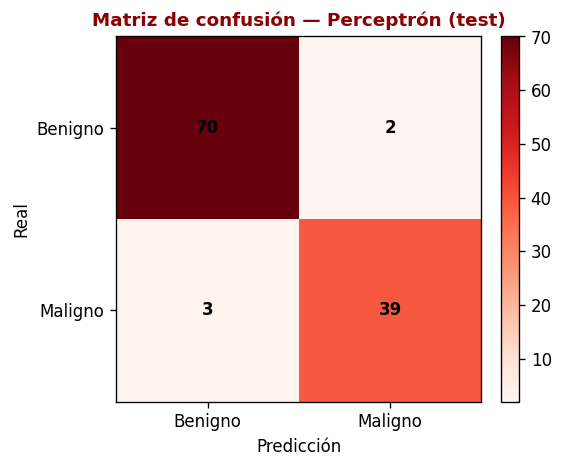

In [14]:
plot_confusion(y_test, y_prob_perc,
               title='Matriz de confusión — Perceptrón (test)',
               threshold=0.5)

### Paso 4.7 — Interpretación del perceptrón

**📝 Tu respuesta (edita esta celda):**

**1. ¿La pérdida de train y validation disminuye de forma coherente?**  
Sí, las curvas de pérdida de entrenamiento y validación disminuyen de forma coherente durante las primeras épocas, lo que indica que el modelo está aprendiendo patrones relevantes presentes en los datos. Además, ambas curvas mantienen valores relativamente cercanos durante gran parte del entrenamiento, sugiriendo una buena capacidad de generalización. Hacia las últimas épocas se observa que la pérdida de entrenamiento continúa disminuyendo mientras que la de validación se estabiliza e incluso aumenta ligeramente, lo que podría indicar un leve inicio de sobreajuste. Sin embargo, la diferencia entre ambas pérdidas es pequeña, por lo que el comportamiento general del modelo puede considerarse adecuado.

**2. ¿El perceptrón parece suficiente para este problema? Justifica con métricas.**  
Los resultados obtenidos sugieren que el perceptrón es suficientemente capaz de abordar este problema de clasificación. El modelo alcanzó una exactitud de 95.61%, una sensibilidad de 92.86%, una especificidad de 97.22%, una precisión de 95.12% y un F1-score de 93.98%, valores que evidencian un desempeño elevado tanto en la detección de casos malignos como benignos. Asimismo, el ROC-AUC de 0.9934 indica una capacidad de discriminación excelente entre ambas clases. Estos resultados sugieren que las clases presentan una separación considerable en el espacio de características y que un modelo lineal simple es capaz de capturar gran parte de la información necesaria para realizar una clasificación efectiva.

**3. ¿Cuántos falsos negativos obtuvo el modelo? ¿Por qué son clínicamente importantes?**  
El modelo obtuvo 3 falsos negativos, lo que significa que tres casos realmente malignos fueron clasificados incorrectamente como benignos. Desde una perspectiva clínica, este tipo de error es especialmente crítico porque puede provocar que un paciente con cáncer no reciba un diagnóstico oportuno ni el tratamiento correspondiente. A diferencia de los falsos positivos, que generalmente conducen a exámenes complementarios adicionales, los falsos negativos pueden retrasar la intervención médica y aumentar el riesgo de progresión de la enfermedad. Por esta razón, la reducción de los falsos negativos suele ser una prioridad en sistemas de apoyo al diagnóstico médico.

**4. Si se quisiera aumentar la sensibilidad para malignidad, ¿qué podríamos modificar en la etapa de decisión?**  
Para aumentar la sensibilidad de la clase maligna se podría reducir el umbral de decisión utilizado para convertir probabilidades en clases. Actualmente se utiliza un umbral de 0.5, por lo que cualquier probabilidad igual o superior a ese valor se clasifica como maligna. Si el umbral se disminuye, por ejemplo a 0.4 o 0.3, más muestras serán clasificadas como malignas, lo que generalmente permite detectar una mayor proporción de casos positivos y reducir los falsos negativos. Sin embargo, este cambio suele incrementar el número de falsos positivos, por lo que es necesario encontrar un equilibrio adecuado entre sensibilidad y especificidad según los objetivos clínicos del problema.


---
# PARTE 3 — Multi-Layer Perceptron y Backpropagation
## Ejercicio 5 — MLP para clasificación diagnóstica

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>


### Paso 5.1 — Definición del MLP

In [15]:
# ── MLP simple para datos tabulares ─────────────────────────────
class MLPClassifier(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.net(x)

seed_everything(42)
mlp = MLPClassifier(n_features).to(device)
print(mlp)
print(f'Número de parámetros entrenables: {sum(p.numel() for p in mlp.parameters())}')

MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)
Número de parámetros entrenables: 641


### Paso 5.2 — Entrenamiento del MLP

In [16]:
# ── Entrenamiento del MLP ───────────────────────────────────────
# TODO 17: define pérdida y optimizador para el MLP
loss_fn_mlp = nn.BCEWithLogitsLoss()
optimizer_mlp = optim.Adam(mlp.parameters(), lr=0.001, weight_decay=1e-4)

hist_mlp = train_model(mlp, train_loader, val_loader,
                       loss_fn_mlp, optimizer_mlp, epochs=150, device=device)

Epoch 001 | train_loss=0.6882 | val_loss=0.6773
Epoch 025 | train_loss=0.0925 | val_loss=0.0963
Epoch 050 | train_loss=0.0462 | val_loss=0.0656
Epoch 075 | train_loss=0.0266 | val_loss=0.0685
Epoch 100 | train_loss=0.0139 | val_loss=0.0683
Epoch 125 | train_loss=0.0080 | val_loss=0.0689
Epoch 150 | train_loss=0.0046 | val_loss=0.0756


### Paso 5.3 — Comparación de curvas de pérdida

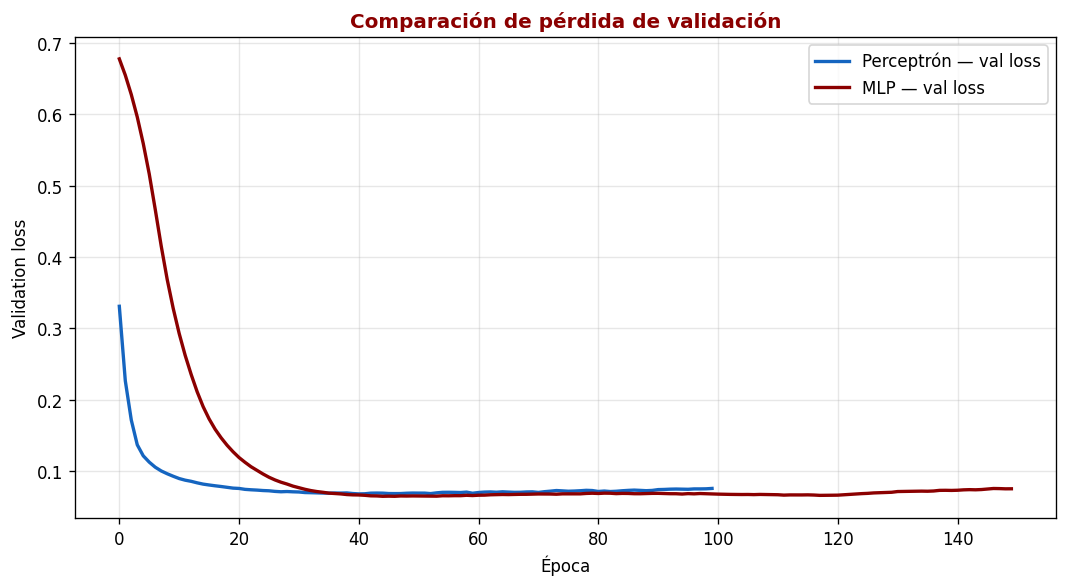

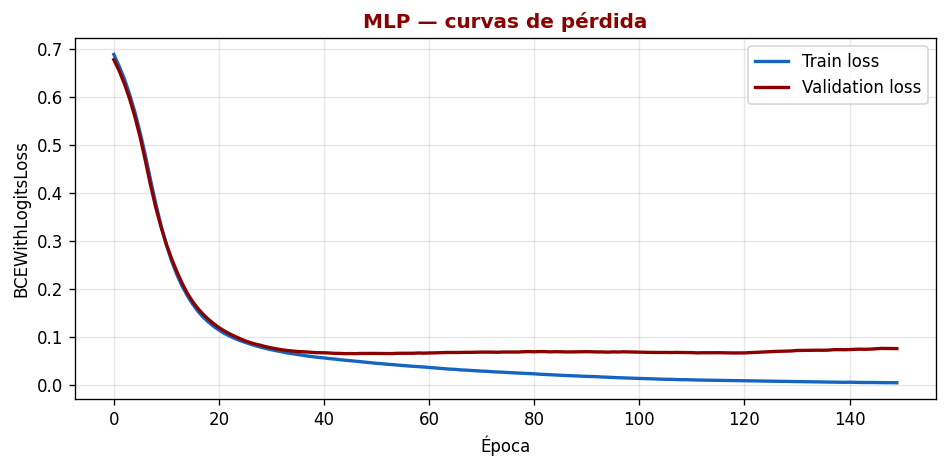

In [17]:
# ── Comparación de curvas ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hist_perc['val_loss'], label='Perceptrón — val loss', color=UPCH_BLUE, lw=2)
ax.plot(hist_mlp['val_loss'], label='MLP — val loss', color=UPCH_RED, lw=2)
ax.set_xlabel('Época')
ax.set_ylabel('Validation loss')
ax.set_title('Comparación de pérdida de validación', fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('challenge6_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

plot_history(hist_mlp, 'MLP — curvas de pérdida')

### Paso 5.4 — Evaluación del MLP

In [18]:
# ── Evaluación del MLP en test ─────────────────────────────────
# TODO 18: predice probabilidades del MLP y calcula métricas clínicas
y_prob_mlp = predict_proba(mlp, X_test_t, device)
metrics_mlp = clinical_metrics(y_test, y_prob_mlp, threshold=0.5)

comparison = pd.DataFrame([metrics_perc, metrics_mlp], index=['Perceptrón', 'MLP'])
comparison[['accuracy', 'sensitivity_recall_malignant', 'specificity_benign',
            'precision_malignant', 'f1_malignant', 'roc_auc', 'fn', 'fp']].round(4)

,accuracy,sensitivity_recall_malignant,specificity_benign,precision_malignant,f1_malignant,roc_auc,fn,fp
Perceptrón,0.9561,0.9286,0.9722,0.9512,0.9398,0.9934,3,2
MLP,0.9649,0.9286,0.9861,0.9750,0.9512,0.9937,3,1


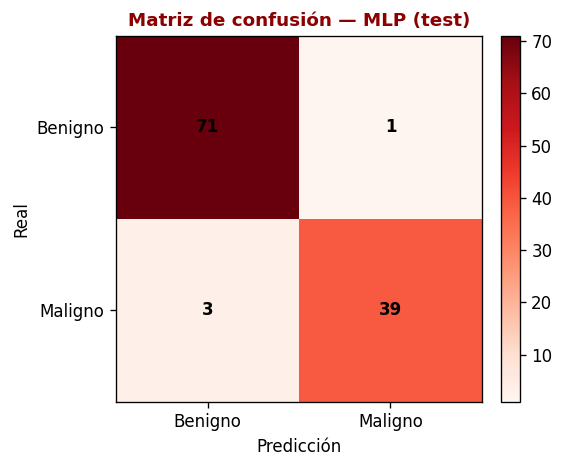

In [19]:
plot_confusion(y_test, y_prob_mlp,
               title='Matriz de confusión — MLP (test)',
               threshold=0.5)

### Paso 5.5 — Interpretación MLP vs perceptrón

**📝 Tu respuesta (edita esta celda):**

**1. ¿El MLP mejora al perceptrón en validation loss o en métricas de test?**  
El MLP muestra una mejora ligera en algunas métricas de desempeño sobre el conjunto de test en comparación con el perceptrón, aunque esta mejora no es consistente en todos los aspectos relevantes. En términos de accuracy, el MLP alcanza 0.9649 frente a 0.9561 del perceptrón, y también presenta mejoras en especificidad (0.9861 vs 0.9722), precisión (0.9750 vs 0.9512) y F1-score (0.9512 vs 0.9398). Sin embargo, no se observa mejora en la sensibilidad para la clase maligna, ya que ambos modelos obtienen el mismo valor de 0.9286, lo que implica que ambos cometen el mismo número de falsos negativos (3 casos).

Respecto a la validation loss, no se evidencia una mejora clara del MLP. Aunque ambos modelos presentan una disminución inicial coherente, el MLP tiende a estabilizarse y posteriormente muestra una ligera degradación hacia las últimas épocas, sin una ventaja consistente frente al perceptrón. En consecuencia, la mejora del MLP es marginal y se concentra principalmente en métricas globales, sin impacto en el objetivo clínico principal.

**2. ¿Hay señales de overfitting? Justifica usando las curvas de pérdida.**  
Sí, se observan señales de sobreajuste leve en el MLP a partir del comportamiento divergente entre la pérdida de entrenamiento y la pérdida de validación. La loss de entrenamiento disminuye de forma sostenida hasta valores muy cercanos a cero, lo que indica una alta capacidad de ajuste del modelo sobre los datos de entrenamiento. Sin embargo, la loss de validación deja de disminuir a partir de aproximadamente las épocas intermedias, estabilizándose alrededor de un valor cercano a 0.065–0.075 e incluso mostrando un ligero incremento hacia las últimas épocas.

Esta separación progresiva entre ambas curvas sugiere que el modelo comienza a memorizar patrones específicos del conjunto de entrenamiento en lugar de aprender representaciones generalizables. En contraste, el perceptrón presenta una evolución más estable y con menor divergencia entre entrenamiento y validación, lo que refuerza la interpretación de que el MLP presenta mayor capacidad de ajuste pero también mayor riesgo de sobreajuste

**3. ¿Qué modelo elegirías para este problema si priorizas sensibilidad para malignidad?**  
Si el criterio de decisión se centra en maximizar la sensibilidad para la detección de casos malignos, el modelo más apropiado es el perceptrón. Esta elección se fundamenta en que ambos modelos presentan un valor idéntico de sensibilidad (0.9286), lo que implica una capacidad equivalente para identificar correctamente los casos positivos. En consecuencia, ambos modelos incurren en el mismo número de falsos negativos (3 casos), los cuales constituyen el tipo de error más crítico en el contexto clínico del diagnóstico de cáncer.

Si bien el MLP presenta mejoras marginales en métricas globales como accuracy, precisión y especificidad, dichas diferencias no se traducen en una mejora del rendimiento respecto a la clase de interés clínico principal. Por lo tanto, al no existir una ganancia en la capacidad de detección de malignidad, el perceptrón resulta preferible debido a su desempeño equivalente en el criterio prioritario, sumado a su menor complejidad estructural y mayor interpretabilidad.

**4. ¿Por qué un modelo más complejo no siempre es clínicamente mejor?**  
Un incremento en la complejidad del modelo no garantiza necesariamente un mejor desempeño clínico, debido a que una mayor capacidad de representación puede conducir al ajuste de patrones específicos del conjunto de entrenamiento que no necesariamente se generalizan a datos no observados. En el presente caso, el MLP exhibe una mayor capacidad de ajuste, evidenciada por una reducción más pronunciada de la pérdida en entrenamiento; sin embargo, esta ventaja no se traduce en mejoras sustanciales en la validación ni en métricas clínicas críticas como la sensibilidad.

Desde una perspectiva clínica, el rendimiento de un modelo debe evaluarse principalmente en función de su impacto en errores de alto costo, particularmente los falsos negativos en diagnósticos de patologías graves. En este sentido, ambos modelos presentan un desempeño equivalente en la detección de casos malignos, lo que indica que la complejidad adicional del MLP no aporta un beneficio clínicamente relevante.

Asimismo, el comportamiento de las curvas de pérdida sugiere la presencia de un leve sobreajuste en el MLP, lo cual puede comprometer su capacidad de generalización en escenarios reales. Por consiguiente, en contextos clínicos, un modelo más simple puede resultar preferible cuando ofrece un desempeño equivalente en métricas críticas, debido a su mayor estabilidad, interpretabilidad y menor riesgo de sobreajuste.


---
# PARTE 4 — Métricas Clínicas y Umbral de Decisión
## Ejercicio 6 — Evaluación final y análisis clínico

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>


### Paso 6.1 — Análisis de umbrales

In [20]:
# ── Sensibilidad al umbral de decisión ──────────────────────────
# TODO 19: prueba al menos 5 umbrales
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
rows = []

for thr in thresholds:
    m = clinical_metrics(y_test, y_prob_mlp, threshold=thr)
    rows.append({
        'threshold': thr,
        'accuracy': m['accuracy'],
        'sensitivity_malignant': m['sensitivity_recall_malignant'],
        'specificity_benign': m['specificity_benign'],
        'precision_malignant': m['precision_malignant'],
        'f1_malignant': m['f1_malignant'],
        'FN': m['fn'],
        'FP': m['fp']
    })

df_thr = pd.DataFrame(rows)
df_thr.round(4)

,threshold,accuracy,sensitivity_malignant,specificity_benign,precision_malignant,f1_malignant,FN,FP
0,0.1,0.9561,0.9286,0.9722,0.9512,0.9398,3,2
1,0.3,0.9649,0.9286,0.9861,0.9750,0.9512,3,1
2,0.5,0.9649,0.9286,0.9861,0.9750,0.9512,3,1
3,0.7,0.9649,0.9286,0.9861,0.9750,0.9512,3,1
4,0.9,0.9737,0.9286,1.0000,1.0000,0.9630,3,0


### Paso 6.2 — Curva ROC

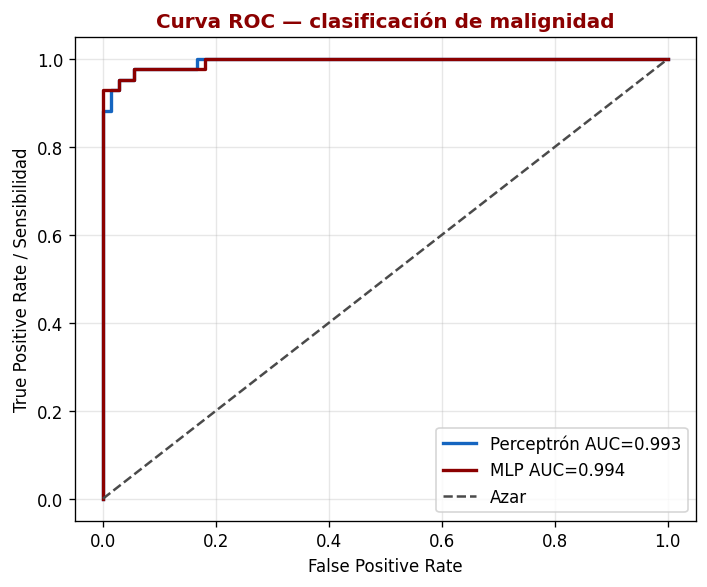

In [21]:
# ── Curva ROC ───────────────────────────────────────────────────
# TODO 20: calcula ROC y AUC para ambos modelos
fpr_perc, tpr_perc, _ = roc_curve(y_test, y_prob_perc)
fpr_mlp,  tpr_mlp,  _ = roc_curve(y_test, y_prob_mlp)
auc_perc = roc_auc_score(y_test, y_prob_perc)
auc_mlp  = roc_auc_score(y_test, y_prob_mlp)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_perc, tpr_perc, color=UPCH_BLUE, lw=2, label=f'Perceptrón AUC={auc_perc:.3f}')
ax.plot(fpr_mlp, tpr_mlp, color=UPCH_RED, lw=2, label=f'MLP AUC={auc_mlp:.3f}')
ax.plot([0, 1], [0, 1], '--', color=UPCH_GRAY, label='Azar')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate / Sensibilidad')
ax.set_title('Curva ROC — clasificación de malignidad', fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('challenge6_roc.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 6.3 — Tabla final comparativa

In [22]:
# ── Tabla final comparativa ────────────────────────────────────
final_cols = ['accuracy', 'sensitivity_recall_malignant', 'specificity_benign',
              'precision_malignant', 'f1_malignant', 'roc_auc', 'tn', 'fp', 'fn', 'tp']

final_table = comparison[final_cols].copy()
final_table.index.name = 'Modelo'
final_table.round(4)

,accuracy,sensitivity_recall_malignant,specificity_benign,precision_malignant,f1_malignant,roc_auc,tn,fp,fn,tp
Modelo,,,,,,,,,,
Perceptrón,0.9561,0.9286,0.9722,0.9512,0.9398,0.9934,70,2,3,39
MLP,0.9649,0.9286,0.9861,0.9750,0.9512,0.9937,71,1,3,39


### Paso 6.4 — Interpretación final

**📝 Tu respuesta (edita esta celda):**

**1. Tabla resumen — completa con los valores obtenidos:**

| Modelo | Accuracy | Sensibilidad maligno | Especificidad benigno | F1 maligno | ROC-AUC | FN | FP |
|---|---:|---:|---:|---:|---:|---:|---:|
| **Perceptrón** | 0.9561 | 0.9286 | 0.9722 | 0.9398 | 0.9934 | 3 | 2 |
| **MLP** | 0.9649 | 0.9286 | 0.9861 | 0.9512 | 0.9937 | 3 | 1 |

---

**2. ¿Cuál modelo elegirías para este problema diagnóstico y por qué?** Elegiríamos el MLP. Aunque ambos modelos presentan la misma sensibilidad (0.9286) y tienen igual cantidad de falsos negativos (3), el MLP supera  al perceptrón en especificidad (0.9861 vs 0.9722). Esto significa que el MLP logra mantener la misma capacidad de detección de tumores malignos, pero es más preciso al descartar los casos benignos.

---

**3. ¿Qué ocurre al bajar el umbral de decisión de 0.50 a 0.30? Discute sensibilidad, especificidad, FN y FP.** En teoría, al reducir el umbral exigimos menos evidencia para clasificar un tumor como maligno, lo que aumentaría la sensibilidad (reduciendo los falsos negativos) a costa de disminuir la especificidad (aumentando los Falsos Positivos). Sin embargo, observando la tabla de análisis de umbrales, no ocurre ningún cambio en las métricas al pasar de 0.50 a 0.30 (Sensibilidad se mantiene en 0.9286, Especificidad en 0.9861, FN=3, FP=1). Esto indica que el modelo está muy seguro de sus predicciones.

---

**4. ¿Por qué no basta con reportar accuracy en este problema?** Porque el Accuracy asume que todos los errores tienen el mismo peso clínico y un accuracy alto aislado no necesariamente implica un mejor modelo. Por ejemplo, en bases de datos médicas donde los casos benignos suelen ser mayoría, un modelo podría obtener un Accuracy alto prediciendo mayoritariamente benigno, pero fallando en su propósito clínico real por presentar altos falsos negativos. Omitir un diagnóstico de cáncer (Falso Negativo) es un error crítico con riesgo de mortalidad, mientras que una falsa alarma (Falso Positivo) es un error tolerable que se resuelve con pruebas confirmatorias.

---

**5. ¿Qué limitaciones tendría este modelo antes de usarlo en un entorno clínico real?**                     
* **Generalización de la muestra:** El modelo fue entrenado con un dataset muy específico extraído de aspirados con aguja fina (FNA). No garantiza el mismo rendimiento en poblaciones con perfiles demográficos distintos o utilizando equipos de biopsia modernos.
* **Dependencia de la extracción manual:** Las variables de entrada de este dataset fueron calculadas a partir de la delimitación celular que un patólogo hizo previamente. El modelo no procesa la imagen cruda, por lo que en la práctica clínica requeriría tiempo humano previo para extraer esas características.
* **Validación prospectiva:** El modelo solo ha sido evaluado de forma retrospectiva. Antes de su uso clínico, requiere estudios prospectivos multicéntricos para evaluar su impacto real en el flujo de trabajo diagnóstico.


---
## Checklist de entrega

Antes de entregar, verifica que tu notebook incluya:

- [X] Respuestas conceptuales completas sobre neurona artificial, perceptrón, MLP y backpropagation.
- [X] Carga correcta del dataset y recodificación clínica: `0=benigno`, `1=maligno`.
- [X] Split estratificado train/validation/test.
- [X] Escalado ajustado solo con train.
- [X] Conversión correcta a tensores y uso de `TensorDataset` + `DataLoader`.
- [X] Definición funcional de `LogisticPerceptron` y `MLPClassifier`.
- [X] Loop explícito de PyTorch con `forward`, `loss`, `zero_grad`, `backward`, `step`.
- [X] Curvas de pérdida de train/validation.
- [X] Matriz de confusión, sensibilidad, especificidad, precisión, F1 y ROC-AUC.
- [X] Análisis de umbral de decisión y discusión clínica de falsos negativos.
- [X] Interpretación final comparando modelo lineal vs MLP.
